# Planewave DFT with Abinit and AbiPy

**CEMDI 2026 -- hands-on session**

This notebook is the companion to the 3-hour CEMDI tutorial on planewave
density-functional theory (DFT) with [Abinit](https://www.abinit.org).
We use [AbiPy](https://github.com/abinit/abipy) throughout: a Python
framework built on top of `pymatgen` that generates Abinit input files,
submits and monitors calculations organized as `Flows`/`Works`/`Tasks`, and
post-processes the native netcdf output files (`GSR.nc`, `DDB`, ...).

The style and many of the code patterns below follow the
[AbiPy Jupyter Book](https://github.com/abinit/abipy_book) lessons -- in
particular `base3/lesson_base3.md` (silicon) and `dfpt/lesson_dfpt.md`
(phonons of AlAs). All the flow-building functions we call are collected in
`workshop_lib.py`, next to this notebook, and are themselves adapted from
the example scripts prepared for this workshop in `AbipyExamples/Production`
and from the DFPT workflow in `GWPT/Production/020-GaP-dfpt`.

We work with a single test system throughout most of the notebook: gallium
arsenide (GaAs), a simple, fast-converging III-V zinc-blende semiconductor.
Silicon is added once, in the band-structure section, for comparison.

**Outline**

1. Setup
2. Building an `AbinitInput`
3. Ground-state total energy of GaAs
4. Convergence studies (ecut, k-points)
5. Band structures: GaAs vs Si
6. Equation of state and the lattice parameter
7. Phonons from DFPT
8. Flows, Works, Tasks and the command-line tools

**Note.** Sections 6 and 7 (equation of state and phonons) are new material
written for this workshop -- there was no ready-made example for them in
`AbipyExamples` yet. The flows they build are deliberately coarse (small
`ecut`, small q-mesh) to keep them cheap; treat the numbers you get as
illustrative rather than converged.

## 1. Setup

Before generating any input, make sure Abinit is on your `$PATH` and that
`~/.abinit/abipy/manager.yml` and `scheduler.yml` are configured for your
machine (templates are available in
`AbipyExamples/Data/Config_files/config_local`). You can check your
installation with:

```
abicheck.py
```

In [1]:
import warnings
warnings.filterwarnings("ignore")  # Ignore warnings for the tutorial

import numpy as np

from abipy import abilab
abilab.enable_notebook()  # Tell AbiPy we are running inside a notebook

# Show matplotlib figures embedded in the notebook.
%matplotlib inline

import workshop_lib as wlib

`workshop_lib` gives us one `build_*_flow()` function per section below,
plus `gaas_structure()` / `si_structure()` and a shared `setup_manager()`.
Let's have a first look at the GaAs structure:

In [4]:
structure = wlib.gaas_structure()
print(structure)

Full Formula (Ga1 As1)
Reduced Formula: GaAs
abc   :   4.065993   4.065993   4.065993
angles:  59.999991  59.999992  59.999994
pbc   :       True       True       True
Sites (2)
  #  SP       a     b     c
---  ----  ----  ----  ----
  0  Ga    0     0     0
  1  As    0.25  0.25  0.25


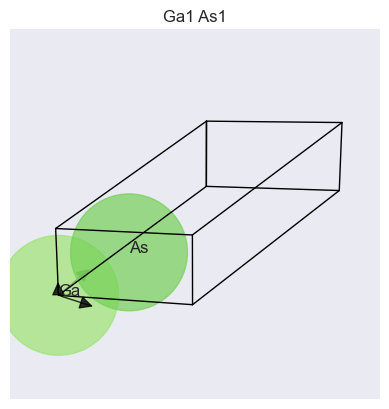

In [5]:
structure.plot();

## 2. Building an `AbinitInput`

An `AbinitInput` is a dict-like object: it *has* a `Structure`, a list of
`Pseudo` objects, and a set of Abinit input variables. `workshop_lib.gs_input`
builds one for a GaAs ground-state (GS) run -- let's look at the source:

In [6]:
abilab.print_source(wlib.gs_input)

In [7]:
gsinp = wlib.gs_input(ecut=6, ngkpt=(8, 8, 8))
print("ecut:", gsinp["ecut"], "Ha")
print("ngkpt:", gsinp["ngkpt"])
gsinp

ecut: 6 Ha
ngkpt: (8, 8, 8)


<AbinitInput at 5600165968>

> **Note.** Indices in Python (and in AbiPy) start at 0: the first band has
> index 0, the first spin channel is 0, etc. Keep this in mind whenever you
> index bands, k-points or spins.

The pseudopotentials come from [PseudoDojo](http://www.pseudo-dojo.org)
(norm-conserving, scalar-relativistic, PBE, in `Data/Pseudos`):

In [8]:
for pseudo in gsinp.pseudos:
    print(pseudo)

<NcAbinitPseudo: Ga.psp8>
  summary: Ga    ONCVPSP-3.2.3.1  r_core=   1.66857   1.75011   1.90252
  number of valence electrons: 13.0
  maximum angular momentum: d
  angular momentum for local part: g
  XC correlation: PBE
  supports spin-orbit: False
  radius for non-linear core correction: 0.0
  hint for low accuracy: ecut: 0.0, pawecutdg: 0.0
  hint for normal accuracy: ecut: 0.0, pawecutdg: 0.0
  hint for high accuracy: ecut: 0.0, pawecutdg: 0.0
<NcAbinitPseudo: As.psp8>
  summary: As    ONCVPSP-3.2.3.1  r_core=   1.76603   1.70395   1.80867
  number of valence electrons: 15.0
  maximum angular momentum: d
  angular momentum for local part: g
  XC correlation: PBE
  supports spin-orbit: False
  radius for non-linear core correction: 0.0
  hint for low accuracy: ecut: 0.0, pawecutdg: 0.0
  hint for normal accuracy: ecut: 0.0, pawecutdg: 0.0
  hint for high accuracy: ecut: 0.0, pawecutdg: 0.0


## 3. Ground-state total energy of GaAs

`build_gs_flow` wraps `gs_input` in a `Flow` with a single SCF task
(this is exactly `Production/004-GaAs-gs/run_gaas_gstate.py`):

In [9]:
abilab.print_source(wlib.build_gs_flow)

In [12]:
flow = wlib.build_gs_flow()
#flow.get_graphviz()

To actually run it, either call `flow.make_scheduler().start()` here in the
notebook, or (recommended for anything non-trivial) build the flow on disk
and launch it from the shell:

```
python run_gaas_gstate.py
abirun.py flow_gaas_gstate scheduler
```

This particular flow has already been run for you, so we can go straight
to the analysis. First, a quick sanity check on the main output file:

In [15]:
abo = abilab.abiopen("flow_gaas_gstate/w0/t0/run.abo")
print(abo)

FileNotFoundError: [Errno 2] No such file or directory: 'flow_gaas_gstate/w0/t0/run.abo'

In [ ]:
print(abo.events)  # Warnings / Comments / Errors, if any

In [ ]:
abo.plot();  # SCF cycle: total energy / residuals vs iteration

The `GSR.nc` file produced by the SCF run has the total energy, forces,
stress tensor and the Kohn-Sham band structure at the end of the run:

In [ ]:
with abilab.abiopen("flow_gaas_gstate/w0/t0/outdata/out_GSR.nc") as gsr:
    print("energy:", gsr.energy, "eV")
    print("pressure:", gsr.pressure, "GPa")
    print(gsr.energy_terms)

> **Warning.** `abiopen` keeps a file descriptor open. Either call
> `.close()` explicitly, or -- better -- use it as a context manager
> (`with abilab.abiopen(...) as f:`) as we just did, so that the file is
> closed automatically.

## 4. Convergence studies

Two Abinit parameters control the accuracy of a planewave DFT calculation
for a given pseudopotential set: the plane-wave cutoff `ecut` and the
density of the k-point mesh. AbiPy makes it easy to launch a family of GS
runs that only differ by one parameter, and to collect the results with a
`Robot`.

### 4.1 ecut convergence

`build_ecut_conv_flow` registers one SCF task per value of `ecut`
(`Production/005-GaAs-conv-ecut`):

In [16]:
abilab.print_source(wlib.build_ecut_conv_flow)

In [17]:
flow = wlib.build_ecut_conv_flow()
print(f"{len(list(flow.iflat_tasks()))} SCF tasks, ecut = "
      f"{[t.input['ecut'] for t in flow.iflat_tasks()]}")

6 SCF tasks, ecut = [10, 15, 20, 25, 30, 35]


Assuming the flow has been run (`flow_gaas_convecut/`), a `GsrRobot` collects
every `GSR.nc` file into a single pandas `DataFrame`:

In [ ]:
with abilab.GsrRobot.from_dir("flow_gaas_convecut") as robot:
    table = robot.get_dataframe()

table[["ecut", "energy", "pressure"]].sort_values("ecut")

`abipy.tools.plotting.ConvergenceAnalyzer` fits/plots a quantity against a
convergence parameter and reports the smallest parameter value for which
the target quantity stays within a given tolerance -- this is exactly what
`Analysis/005-GaAs-conv-ecut/plot_ecut_conv.py` does:

In [ ]:
from abipy.tools.plotting import ConvergenceAnalyzer

ecut_Ha = table.sort_values("ecut")["ecut"].tolist()
ene_per_atom_eV = (table.sort_values("ecut")["energy"] / len(structure)).tolist()

ca = ConvergenceAnalyzer.from_xy_label_vals(
    "ecut (Ha)", ecut_Ha, "E/natom (eV)", ene_per_atom_eV, tols=1e-3)
ca.plot();

### 4.2 k-point convergence

Same idea, but now `ecut` is fixed and we vary the k-mesh via
`set_autokmesh(nk)`, which generates an increasingly dense homogeneous mesh
(`Production/006-GaAs-conv-kpt`):

In [ ]:
abilab.print_source(wlib.build_kpt_conv_flow)

In [ ]:
with abilab.GsrRobot.from_dir("flow_gaas_convkpt") as robot:
    table = robot.get_dataframe()

table[["energy", "pressure"]]

`Analysis/006-GaAs-conv-kpt/plot_kpt_conv.py` converts each k-mesh into an
"inverse k-point distance" (a rough, mesh-independent measure of density) so
that runs with different `kptrlatt` can be compared on the same x-axis:

In [ ]:
k_recip_dist, ene_per_atom_eV = [], []

with abilab.GsrRobot.from_dir("flow_gaas_convkpt") as robot:
    for label, gsr in robot:
        ene_per_atom_eV.append(gsr.energy_per_atom)
        rprim = gsr.structure.lattice.matrix
        kptrlatt = gsr.kpoints.ksampling["kptrlatt"]
        R_latt = np.dot(kptrlatt, rprim)
        k_latt = 2 * np.pi * np.linalg.inv(R_latt)
        kmin = max(np.linalg.norm(k) for k in k_latt)
        k_recip_dist.append(1 / kmin)

ca = ConvergenceAnalyzer.from_xy_label_vals(
    "Inverse k-point distance (Ang)", k_recip_dist,
    "E/natom (eV)", ene_per_atom_eV, tols=1e-3)
ca.plot();

> **Exercise.** Redo the ecut convergence study for silicon
> (`wlib.si_structure()`), reusing `gs_input` as a template. Is the
> converged `ecut` similar to the one you found for GaAs? Should it be?

## 5. Band structures: GaAs vs Si

A band-structure flow chains two datasets: a GS run on a homogeneous k-mesh
(to get the density), then a non-self-consistent (NSCF) run along a
high-symmetry k-path using that density. `flowtk.bandstructure_flow` builds
this two-task work for us; `build_gaas_ebands_flow` /
`build_si_ebands_flow` wrap it for each material
(`Production/007-GaAs-ebands`, `Production/008-Si-ebands`):

In [ ]:
abilab.print_source(wlib.build_gaas_ebands_flow)

In [ ]:
with abilab.abiopen("flow_gaas_ebands/w0/t1/outdata/out_GSR.nc") as gsr:
    gaas_ebands = gsr.ebands

fig = gaas_ebands.plot(color="b", show=False)
fig.gca().set_ylim(-10, 10)
fig.gca().set_title("GaAs");

In [ ]:
with abilab.abiopen("flow_si_ebands/w0/t1/outdata/out_GSR.nc") as gsr:
    si_ebands = gsr.ebands

fig = si_ebands.plot(color="g", show=False)
fig.gca().set_ylim(-10, 10)
fig.gca().set_title("Si");

GaAs has a direct gap at $\Gamma$, while silicon's fundamental gap is
indirect ($\Gamma \to$ near X). Both are visible on the two plots above --
this is a good moment to discuss why LDA/GGA systematically underestimate
these gaps, and what the standard corrections are ($GW$, hybrid
functionals, scissor operators).

> **Note.** `ElectronBands` objects also expose `.plot_with_edos(edos)` to
> overlay the density of states next to the bands, and `to_bxsf()` /
> `.plot_fermi_surface()` for metals -- not needed for GaAs/Si, but worth
> knowing about.

## 6. Equation of state and the lattice parameter

Rather than running a full ionic + cell relaxation (`ionmov`/`optcell`),
which can be finicky to converge live in a 3h session, we use the
equation-of-state (EOS) approach: run the SCF ground state at several
isotropically-scaled volumes around the experimental structure, then fit a
Birch-Murnaghan equation of state to $E(V)$. This is the same strategy used
in the AbiPy `base3` (silicon) lesson to determine the lattice parameter.

`build_eos_flow` builds one SCF task per scaled volume:

In [ ]:
abilab.print_source(wlib.build_eos_flow)

In [ ]:
with abilab.GsrRobot.from_dir("flow_gaas_eos") as robot:
    table = robot.get_dataframe()

table = table.sort_values("volume")
table[["volume", "energy"]]

In [ ]:
eos = abilab.EOS.Birch_Murnaghan()
fit = eos.fit(table["volume"].values, table["energy"].values)
print(fit)
fit.plot();

The fit reports the equilibrium volume $V_0$, bulk modulus $B_0$ and its
pressure derivative $B_0'$. From $V_0$ you can back out the equilibrium
lattice parameter $a_0 = (4 V_0)^{1/3}$ for this zinc-blende (4 atoms/cell)
structure, and compare it with the experimental value (~5.65 Ang for GaAs).

> **Exercise.** Compare the fitted `ecut=12` Ha equilibrium volume with
> what you'd get at `ecut=24` Ha. How much does $a_0$ shift? Is `ecut=12`
> Ha good enough for this particular quantity, even if it wasn't fully
> converged for the total energy in Section 4?

## 7. Phonons from DFPT

Density-functional perturbation theory (DFPT) gives access to phonons,
Born effective charges and the dielectric tensor without finite
displacements. AbiPy's `PhononFlow` automates the whole workflow: a GS run
that produces the ground-state wavefunctions (`WFK`), followed by one DFPT
task per symmetry-irreducible atomic perturbation and q-point.

`build_phonon_flow` is a simplified, GaAs version -- coarser `ecut`,
k-mesh and q-mesh, for speed -- of the production phonon workflow used for
GaP in `GWPT/Production/020-GaP-dfpt/1-run_phonons.py`:

In [ ]:
abilab.print_source(wlib.build_phonon_flow)

In [ ]:
flow = wlib.build_phonon_flow()
#flow.get_graphviz()

Once the flow has completed, all the DFPT results (dynamical matrices,
Born effective charges, dielectric tensor) are merged into a single `DDB`
file. This is the entry point for essentially all the post-processing:

In [ ]:
ddb = abilab.abiopen("flow_gaas_phonons/w1/outdata/out_DDB")
print(ddb)

`ddb.anaget_phbst_and_phdos_files` calls `anaddb` behind the scenes to
Fourier-interpolate the dynamical matrix onto a dense q-mesh (for the
phonon DOS) and along a high-symmetry q-path (for the phonon band
structure):

In [ ]:
phbst_file, phdos_file = ddb.anaget_phbst_and_phdos_files(
    nqsmall=10, ndivsm=10, asr=2, chneut=1, dipdip=1,
    dos_method="tetra", lo_to_splitting=True)

phbands = phbst_file.phbands
phbands.plot_with_phdos(phdos_file.phdos);

> **Note.** `lo_to_splitting=True` accounts for the LO-TO splitting at
> $\Gamma$ that polar materials like GaAs show, using the Born effective
> charges and the dielectric tensor also stored in the `DDB`.

Born effective charges and the dielectric tensor can be inspected directly:

In [ ]:
epsinf, becs = ddb.anaget_epsinf_and_becs()
print("Electronic dielectric tensor:\n", epsinf)
print("\nBorn effective charges:")
print(becs)

In [ ]:
phbst_file.close()
phdos_file.close()
ddb.close()

## 8. Flows, Works, Tasks and the command-line tools

Every calculation in this notebook was expressed as a `Flow` made of
`Work`s made of `Task`s -- the same abstraction whether you're running one
SCF task or the hundreds of DFPT tasks behind the phonon flow. A few
commands worth knowing for automating and inspecting flows outside the
notebook:

```
abirun.py FLOWDIR scheduler      # run (or resume) a flow until completion
abirun.py FLOWDIR status         # check the status of all tasks
abiopen.py FILE                  # open any Abinit netcdf/output file in ipython
abiopen.py FILE -nb              # ... or generate a Jupyter notebook from it
abiopen.py FILE -e               # ... or get a quick summary plot ("expose")
abicomp.py gsr FILE1 FILE2 ...   # compare several files of the same kind
```

`Robots` (`GsrRobot`, `DdbRobot`, ...) are the programmatic equivalent of
`abicomp.py`: they collect many files of one kind and build pandas
DataFrames you can filter, sort, and plot -- this is what powered the
convergence studies and the equation-of-state fit above.

## Wrap-up

In three hours we went from a bare `Structure` to: a converged total
energy, ecut/k-point convergence studies, band structures for two
materials, an equation-of-state fit for the lattice parameter, and a DFPT
phonon calculation with Born effective charges -- all driven by the same
handful of AbiPy abstractions (`AbinitInput`, `Flow`, `abiopen`, `Robot`).

For more worked examples, see the
[AbiPy Jupyter Book](https://github.com/abinit/abipy_book), the
[AbiPy plot gallery](https://abinit.github.io/abipy/gallery/index.html) and
the [AbiPy flow gallery](https://abinit.github.io/abipy/flow_gallery/index.html).